In [43]:
import pandas as pd
import numpy as np

In [44]:
df = pd.read_csv("Mental Health Dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (186360, 17)


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [45]:
df = df.drop(columns=["Timestamp"])

In [46]:
df["self_employed"] = df["self_employed"].fillna("Unknown")

# remove rows where treatment is missing
df = df.dropna(subset=["treatment"])

print(df.isnull().sum())

Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64


In [47]:
df["treatment"] = df["treatment"].map({"Yes": 1, "No": 0})

print(df["treatment"].value_counts())

treatment
1    98469
0    87890
Name: count, dtype: int64


In [48]:
X = df.drop("treatment", axis=1)
y = df["treatment"]

In [49]:
X_encoded = pd.get_dummies(X)

print("Encoded Shape:", X_encoded.shape)

Encoded Shape: (186359, 78)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (149087, 78)
Testing Size: (37272, 78)


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7244312084138227

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.69      0.70     17698
           1       0.73      0.76      0.74     19574

    accuracy                           0.72     37272
   macro avg       0.72      0.72      0.72     37272
weighted avg       0.72      0.72      0.72     37272


Confusion Matrix:
 [[12218  5480]
 [ 4791 14783]]


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7522000429276668

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.69      0.73     17698
           1       0.74      0.80      0.77     19574

    accuracy                           0.75     37272
   macro avg       0.75      0.75      0.75     37272
weighted avg       0.75      0.75      0.75     37272


Confusion Matrix:
 [[12289  5409]
 [ 3827 15747]]


In [53]:
!pip install shap

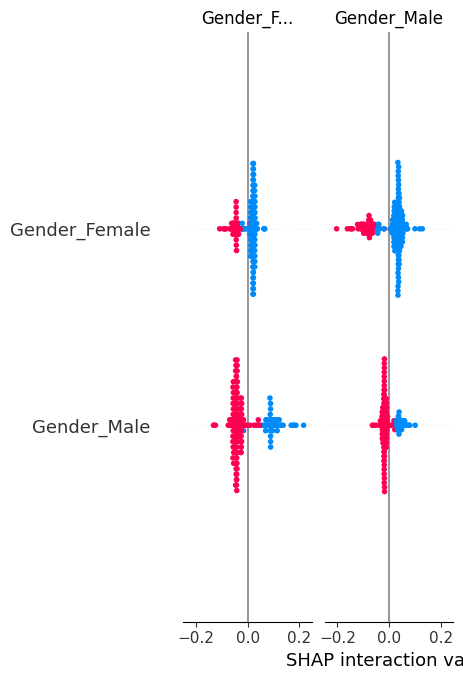

In [55]:
import shap

# take a smaller sample for faster computation
sample = X_test.sample(200, random_state=42)

# create explainer
explainer = shap.TreeExplainer(rf_model)

# compute shap values
shap_values = explainer.shap_values(sample)

# plot
shap.summary_plot(shap_values, sample)

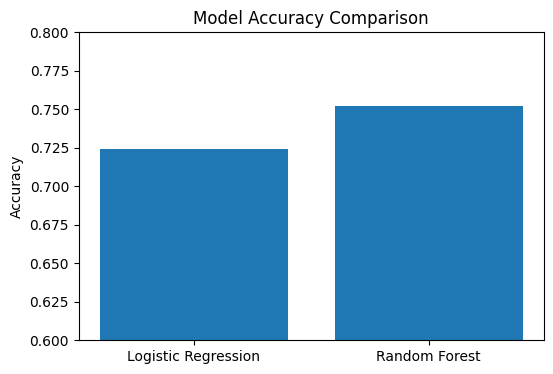

In [57]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
accuracy = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.6, 0.8)
plt.show()

In [58]:
import pickle

# save trained model
pickle.dump(rf_model, open("model.pkl", "wb"))